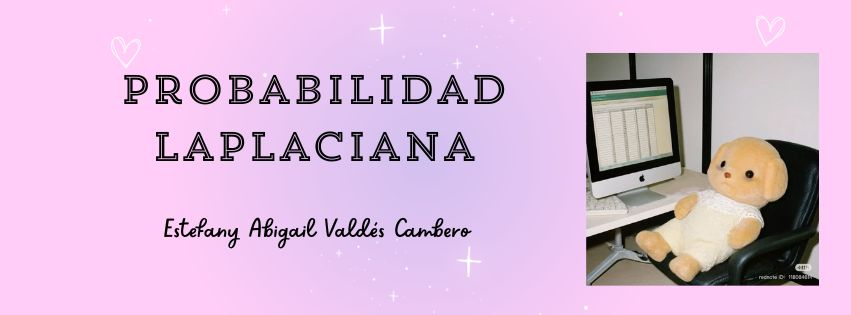

In [1]:
import numpy as np
import numpy.random as npr # Para generar números aleatorios

import matplotlib.pyplot as plt # Para crear gráficas



In [2]:
from scipy.stats import bernoulli, binom, poisson, geom, hypergeom, nbinom
from scipy.stats import expon, norm, gamma, beta


import random

import plotly.express as px
import plotly.graph_objects as go

import pandas as pd
import seaborn as sns

# Introducción

La definición clásica de probabilidad fue introducida en 1812 por Pierre-Simon Laplace, se basó en el concepto de equiprobabilidad como una propiedad objetiva de los eventos asocidados a un experimento aleatorio.

En probabilidad se trabaja con conceptos como lo son:

1. **Conjuntos**
2. **Experimento aleatorio**: Es un experimento $\varepsilon$ que reproducido en condiciones idénticas puede conducir a varios resultados, en el cual no se puede predecir el resultado.
3. **Espacio de estados**: El espacio de todos los posibles resultados de un experimento aleatorio y es denotado por $\Omega$.

## Ejemplos

El lanzamiento de una moneda: $Ω={águila, sol}$.

El lanzamiento de un dado: $Ω={1,2,3,4,5,6}$.

El lanzamiento de un dardo en un círculo de 30 cm de diámetro: $Ω={(x,y): \sqrt{x^2+y^2} ≤ 15}$

Romeo espera a Julieta, el cual va desde 1 minuto a 1 hora: $Ω=[0,1]$.

Cuando estudiamos el tiempo de vida de una bacteria: $Ω=[0,∞)$.

4. **Evento aleatorio**: Es un subconjunto de $\Omega$ donde se puede decir si el experimento se realiza o no.



Un espacio de probabilidad es una terna $(\Omega,\mathscr{F},\mathbb{P})$ donde $\Omega$ es un conjunto no vacío, $\mathscr{F}$ es la familia de subconjuntos de $\Omega$ y $\mathbb{P}$ es una medida de probabilidad , la cual le asigna un número no negativo a un evento, esta última es una función $\mathbb{P}: \mathscr{F} \rightarrow [0,1]$ que verifica:

1. No negatividad
2. Normalización
3. $\sigma$ - aditividad


# Modelo Clásico (Laplaciano)

Si tenemos $\Omega = \{w_1,w_2,...,w_n\}$ es un conjunto finito no vacío y $\mathscr{F}=P(\Omega)$, los elementos $\{w_i\}$ tienen la misma probabilidad $\frac{1}{n}$ y se tiene que la probabilidad de un evento $A$ es:

$$\mathbb{P}=\frac{\text{casos favorables}}{\text{casos totales}}=\frac{|A|}{|\Omega|} \text{ ,para toda A} \subset \Omega$$

**Ejemplo.** Sea el experimento de lanzar una moneda 3 veces, de manera independiente, es decir, el $i$-ésimo lanzamiento no afecta al $i+1$ lanzamiento. El espacio muestral es:

$$ \Omega = \{A,S\} \times \{A,S\} \times \{A,S\} = \{A,S\}^3, A = \{águilas\}, S = \{soles\}$$

$$ A \times B = \{(a,b) \mid a\in A, b \in B\}$$

y

$$\Omega =\{(s,s,s), (s,a,s), (s,s,a), (s,a,a), (a,a,a), (a,s,s), (a,s,a), (a,a,s)\}$$

y se tiene que $|\Omega| = 2^3 = 8$

Sean los eventos siguientes:

- $A$: todos los resultados son águilas
- $S$: todos los resultados son soles
- $E$: por lo menos un resultado es sol (1 o 2 o 3 son soles)


### Vamos a crear el espacio muestral


In [3]:
# Vamos a importar el siguiente módulo
import itertools as it
from itertools import product

In [4]:
# Set - lo convierte en conjunto
# Product - generar las tuplas de longitud 3
Omega = set(product({"A","S"}, repeat=3))
Omega

{('A', 'A', 'A'),
 ('A', 'A', 'S'),
 ('A', 'S', 'A'),
 ('A', 'S', 'S'),
 ('S', 'A', 'A'),
 ('S', 'A', 'S'),
 ('S', 'S', 'A'),
 ('S', 'S', 'S')}

In [5]:
# La carniladidad del conjunto es:
len(Omega)

8

### Vamos a crear el evento A


In [6]:
# Para el evento A_1: el primer elemento es águila

A_1 = {om for om in Omega if om[0] == "A"}
A_1

{('A', 'A', 'A'), ('A', 'A', 'S'), ('A', 'S', 'A'), ('A', 'S', 'S')}

In [7]:
# Para el evento A_2: el segundo elemento es águila
A_2 = {om for om in Omega if om[1] == "A"}
A_2

{('A', 'A', 'A'), ('A', 'A', 'S'), ('S', 'A', 'A'), ('S', 'A', 'S')}

In [8]:
# Para el evento A_3: el tercer elemento es águila
A_3 = {om for om in Omega if om[2] == "A"}
A_3

{('A', 'A', 'A'), ('A', 'S', 'A'), ('S', 'A', 'A'), ('S', 'S', 'A')}

In [9]:
# Para el evento A: los tres elementos son águila
A = A_1.intersection(A_2.intersection(A_3))
A

{('A', 'A', 'A')}

In [10]:
card_A = len(A)

In [11]:
P_A = card_A / len(Omega)
P_A

0.125

Ahora, si quiero expresar mi resultado en fracción utilizamos fractions


In [12]:
from fractions import Fraction

In [13]:
# Definimos la función de probabilidad Laplaciana
def p(E,Omega):
    p = Fraction(len(E), len(Omega))
    return p

In [14]:
Pro_A = p(A, Omega)
Pro_A

Fraction(1, 8)

In [15]:
print(Pro_A)

1/8


### Vamos a crear el evento S


In [16]:
# Para el evento S: los tres elementos son sol

S_1 = {om for om in Omega if om[0] == "S"}
S_2 = {om for om in Omega if om[1] == "S"}
S_3 = {om for om in Omega if om[2] == "S"}

S = S_1.intersection(S_2.intersection(S_3))
S

{('S', 'S', 'S')}

In [17]:
card_S = len(S)
P_S = card_S / len(Omega)
P_S

0.125

In [18]:
Pro_S = p(S, Omega)
Pro_S

Fraction(1, 8)

In [19]:
print(Pro_S)

1/8


### Vamos a crear el evento E


In [20]:
E = S_1.union(S_2.union(S_3))
E

{('A', 'A', 'S'),
 ('A', 'S', 'A'),
 ('A', 'S', 'S'),
 ('S', 'A', 'A'),
 ('S', 'A', 'S'),
 ('S', 'S', 'A'),
 ('S', 'S', 'S')}

In [21]:
card_E = len(E)
P_E = card_E / len(Omega)
P_E

0.875

In [22]:
Pro_E= p(E, Omega)
Pro_E

Fraction(7, 8)

In [23]:
print(Pro_E)

7/8


# Probabilidad Condicional


Si añadimos condiciones a nuestro experimento aleatorio, la probabilidad cambia.

Definimos la probabilidad de que ocurra un evento $A$ **sabiendo** que ocurre un evento $B$, de la siguiente manera:

$$\mathbb{P}(A \mid B) \frac{\mathbb{A \cap B}}{\mathbb{P}(B)} = \frac{|A \cap B|}{|B|}$$

donde $$\mathbb{P}(B) > 0$$


In [24]:
# Vamos a definir la función de probabilidad condicional

def p_cond(E, F):
    return len(E&F) / len(F)

Queremos calcular la probabilidad condicional de los eventos siguientes:

- $B$: el primer lanzamiento es águila
- $C$: dos de los resultados son águila (exactamente)

Quiero $\mathbb{P}(B\mid C)$


In [25]:
# Para el evento B: el primer elemento es águila

B = {om for om in Omega if om[0] == "A"}

In [26]:
# Para el evento C: dos resultados son águila (exactamente)

C = {om for om in Omega if om.count("A") == 2}
C

{('A', 'A', 'S'), ('A', 'S', 'A'), ('S', 'A', 'A')}

In [27]:
p_BC = p_cond(B, C)
print(p_BC)
print(Fraction(p_BC))

0.6666666666666666
6004799503160661/9007199254740992


In [28]:
p_CB = p_cond(C, B)
print(p_CB)
print(Fraction(p_CB))

0.5
1/2


## Independencia de eventos


Decimos que dos eventos $A$ y $B$ son independientes si

$$\mathbb{P}(A \cap B) = \mathbb{P}(A)\mathbb{P}(B)$$


In [29]:
def prob(E):
    return len(E) / len(Omega)

In [30]:
def indep(E, F):
    return prob(E&F) == prob(E)*prob(F)

In [31]:
indep(B,C)

False

**Ejemplo.** Sea el experimento aleatorio de lanzar un dado honesto 2 veces. Sabemos que:

$$\Omega = \{(i,j)\mid i,j \in \{1,2,3,4,5,6\}\} $$

y además $|\Omega| = 6^2 = 36$


In [32]:
Omega_dado = set(product([1,2,3,4,5,6], repeat=2))
Omega_dado
# Cardinalidad del nuevo espacio muestral
card_dado = len(Omega_dado)
card_dado

36

Definimos el evento

- $S_n$: la suma de los dados es $n$, donde $n\in\{2,\dots,12\}$

$$ S_n = \{(i,j) \in \Omega \mid i+j = n \}$$


In [33]:
def S(n):
    Sn = {(i,j) for i in range(1,7) for j in range(1,7) if i+j == n}
    return Sn

In [34]:
S_siete = S(7)
S_siete

{(1, 6), (2, 5), (3, 4), (4, 3), (5, 2), (6, 1)}

In [35]:
len(S_siete)/card_dado

0.16666666666666666

# Probabilidad Geométrica

En este modelo se busca encontrar probabilidades de la siguiente manera:

$$\mathbb{P}(A)=\frac{\text{área deseada}}{\text{área total}}$$

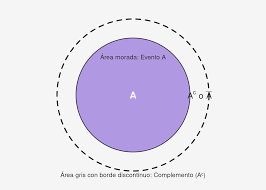

Se puede utilizar cuando trabajamos por ejemplo con distancias. Este tipo de probabilidad supone que todos los puntos dentro de la región considerada tienen la misma posibilidad de ser seleccionados.

## Ejemplo

Un ejemplo clásico es el problema del encuentro de Romeo y Julieta, el cual se muestra a continuación:

# El problema del encuentro


Romeo y Julieta planean encontrarse en un lugar específico entre $[0,60]$ minutos (1 hora).

- Si romeo llega primero, entonces piensa esperar 10 minutos
- Si julieta llega primero, entonces piensa esperar 10 minutos

Se elige un número al azar entre $[0,60]$, y supongamos que el par de números se elige sobre el cuadrado de modo que la probabilidad de un evento sea el área favorable entre el área total.

Sea
$A$: Romeo y Julieta se encuentran a una distancia de 10 minutos

Me gustaría encontrar la probabilidad de $A$.


In [36]:
import numpy as np
import matplotlib.pyplot as plt

La probabilidad del evento A es: 0.311.


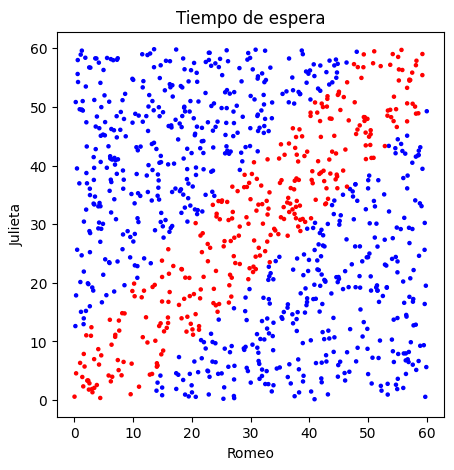

In [37]:
# Vamos a generar 1000 simulaciones
muestra = 1000

# Generamos los tiempos aleatorios entre [0, 60]
# x: tiempo de llegada de Romeo
# y: tiempo de llegada de Julieta

x = np.random.uniform(0,60,muestra)
y = np.random.uniform(0,60,muestra)

# Añadimos nuestra condición de encuentro
encuentro = np.where(abs(x-y)<= 10, 'r','b')

# Si la diferencia entre los tiempos es menor o igual que 10, entonces se encuentran (rojo)
# si no, no se encuentran (azul)

# Ahora calculamos la probabilidad de que se encuentren
k = 0
for elemento in encuentro:
    if elemento == 'r':
        k += 1 # añadir a k
print("La probabilidad del evento A es: {}.".format(k/muestra))

# Para graficar los puntos de encuentro, hacemos una gráfica de dispersión
plt.figure(figsize=(5,5)) # tamaño de la figura
plt.scatter(x,y,c=encuentro,s=5) # s = 1 es un pixel
plt.title("Tiempo de espera")
plt.ylabel("Julieta")
plt.xlabel("Romeo")
plt.show()


# Probabilidad Frecuentista

En esta rama de la probabilidad, quien nos da información acerca del experimento es la repetición del evento.

Por ejemplo, si consideramos el experimento de lanzar una moneda:

1 lanzamiento: 1 cara ← No podemos decir nada

300 lanzamientos: 200 caras y 100 soles \leftarrow Empezamos a hacernos preguntas

3000 lanzamientos: 2000 caras y 100 soles ← Es casi seguro que la moneda está cargada

En este caso la frecuencia empírica del evento cara es $\frac{2000}{3000}$

Considerando justamente el experimento de lanzar una moneda no justa tenemos:

In [38]:
import random

In [39]:
def volado(p): # Regresa la proba de obtener sol
    return "sol" if random.random() < p else "aguila"
    # random.random() genera un número entre 0 y 1

In [40]:
volado(0.4)

'aguila'

In [41]:
# Vamos a realizar 10 volados con p = 0.4
vol = [volado(0.4) for i in range(10)] # crear una lista
# range(n): crea un contador que va  de 0 hasta n
vol

['sol',
 'aguila',
 'aguila',
 'sol',
 'aguila',
 'aguila',
 'aguila',
 'sol',
 'aguila',
 'aguila']

In [42]:
# Para contar el número de soles en una lista
vol.count('sol')

3

Ahora, vamos a simular nuestra probabilidad frecuentista:

Un experimento con 1,000 volados (individual) y puedo repetir 500 experimentos (500 de nosotros)


In [43]:
# Creamos una lista vacía para almacenar probabilidades (frecuencia)

p = []

for i in range(500): # Realizamos 500 experimentos
    N = 1000 # Cada experimento tiene 1,000 volados
    resultados = [] # almacenar aguilas y soles

    for j in range(N):
        resultado = volado(0.7)
        resultados.append(resultado)

    n_soles = resultados.count("sol") # Cuenta el # de soles
    p_soles = n_soles / N #Proba frecuentista

    # Añadir estas probabilidades a la lista p

    p.append(p_soles)

    # Probabilidad frecuentista promedio
    p_soles_prom = sum(p)/len(p) # Por la ley de los grandes números

p_soles_prom

0.6995779999999999

In [44]:
# Función completa by Misael
# Creamos una lista vacía para almacenar probabilidades (frecuencia)

def probafrec(p ,experimentos , volados):
    p_total = []
    for i in range(experimentos):
        resultados = []
        for j in range(volados):

            resultado = "sol" if random.random() < p else "aguila"
            resultados.append(resultado)

        n_soles = resultados.count("sol") # Cuenta el # de soles
        p_soles = n_soles / N #Proba frecuentista

        # Añadir estas probabilidades a la lista p

        p_total.append(p_soles)

        # Probabilidad frecuentista promedio
        p_soles_prom = sum(p_total)/len(p_total) # Por la ley de los grandes números

    return p_soles_prom


In [45]:
probafrec (0.9,500,1000)

0.900346